# 26_01 Z-score 이상탐지 해석

In [14]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['Malgun Gothic']


### 실습 1. MIMII 데이터 불러오기·구조 확인
목표 : 데이터를 불러와 크기와 정답 분포를 확인

단계
- 특징값 파일을 불러오기
- 크기로 행·열 개수를 확인
- 정답 분포로 정상·이상 개수를 확인

예상 결과
- 220행 4열, 정상 180·이상 40


In [15]:
# 실습1 코드
mimii = pd.read_csv("..\\Data\\26_mimii_features.csv", encoding='utf-8')

print(mimii.info())
print()
print(mimii.head(10).to_markdown())

<class 'pandas.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   rms                 220 non-null    float64
 1   spectral_centroid   220 non-null    float64
 2   zero_crossing_rate  220 non-null    float64
 3   label               220 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 7.0 KB
None

|    |    rms |   spectral_centroid |   zero_crossing_rate |   label |
|---:|-------:|--------------------:|---------------------:|--------:|
|  0 | 0.0659 |              1982.7 |               0.1171 |       0 |
|  1 | 0.0393 |              2160.8 |               0.0821 |       0 |
|  2 | 0.0443 |              2065.9 |               0.091  |       0 |
|  3 | 0.0458 |              1884.4 |               0.1072 |       0 |
|  4 | 0.0698 |              2430.9 |               0.0864 |       0 |
|  5 | 0.074  |              2728.5 |               0.0983 |

In [16]:
print("정답 개수:", mimii["label"].value_counts().to_dict())

정답 개수: {0: 180, 1: 40}


### 실습 2. 특징값 분포 정상·이상 비교
목표 : 한 특징의 분포를 정상·이상 색으로 나눠 그려 차이를 보기

단계
- 특징 하나를 히스토그램으로 그리기
- 정답으로 색을 나눠 겹쳐 그리기
- 정상·이상 분포가 어디서 갈리는지 관찰

예상 결과
- 이상은 정상보다 값이 큰 쪽으로 분포가 치우침


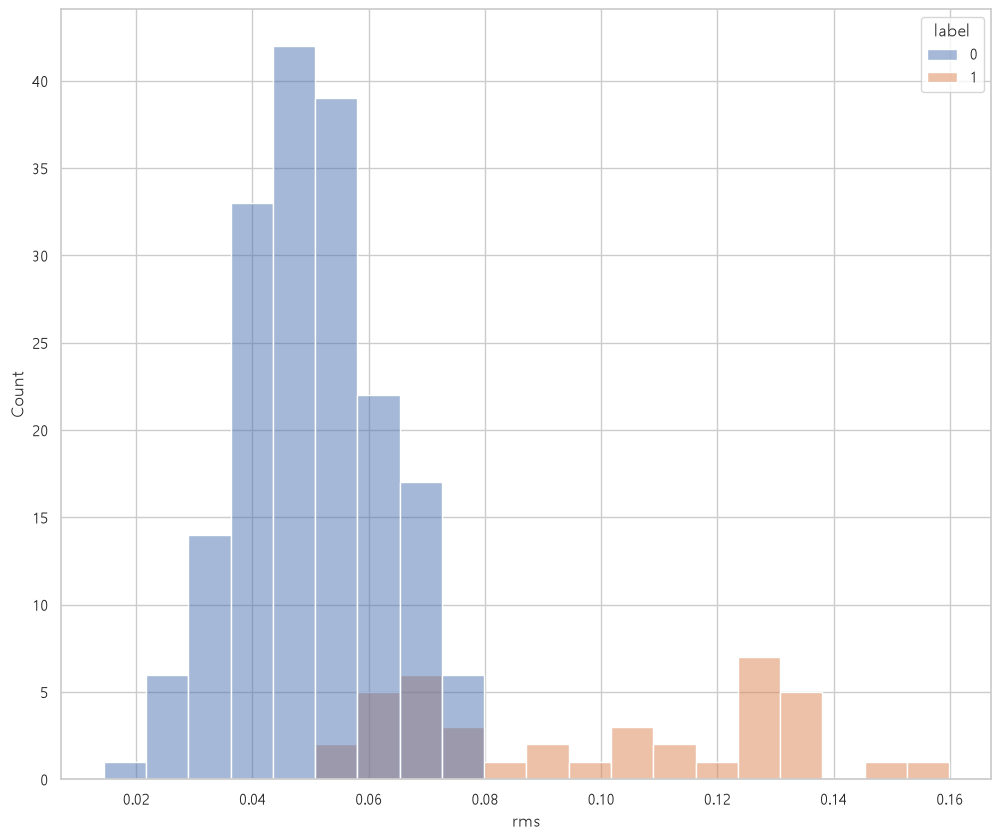

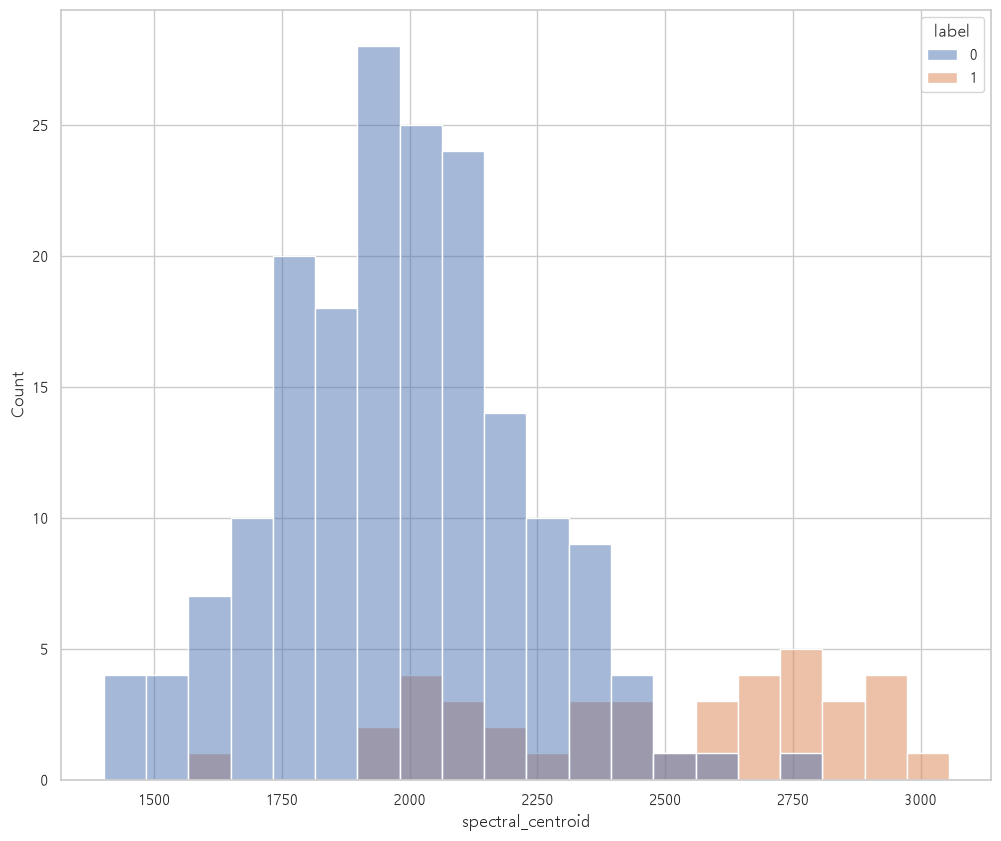

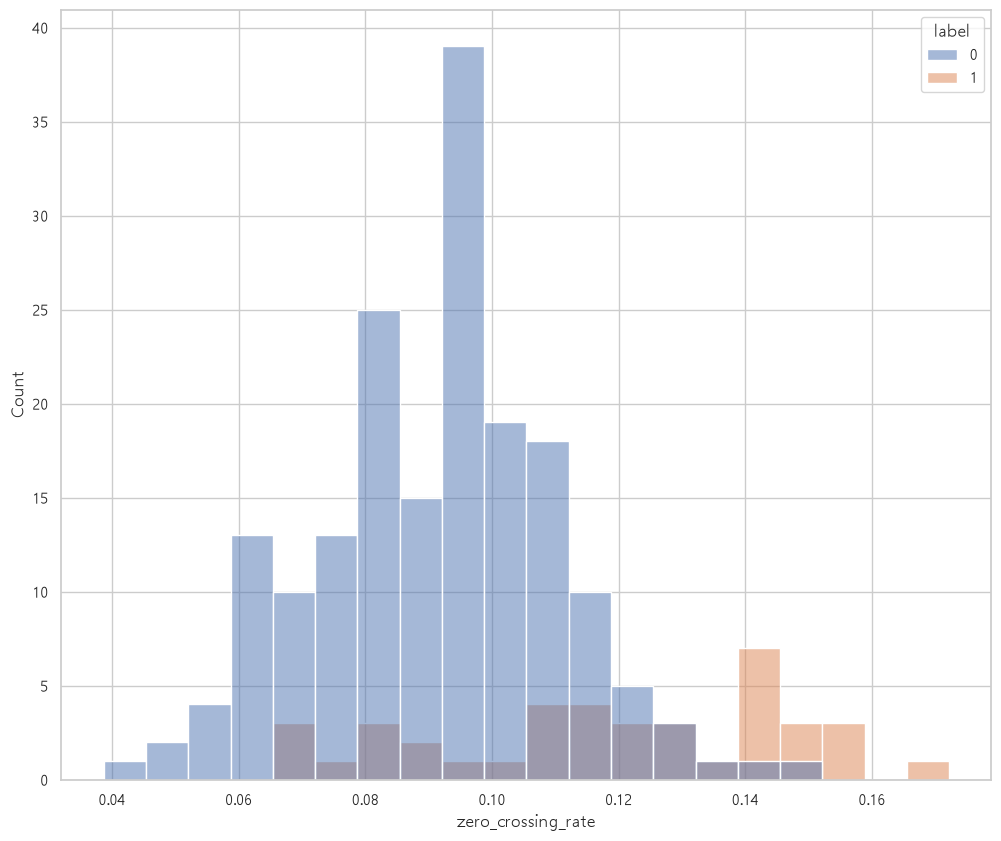

In [17]:
# 실습2 코드
plt.figure(figsize=(12,10))
sns.histplot(data=mimii, x='rms', bins=20, hue='label')

plt.figure(figsize=(12, 10))
sns.histplot(data=mimii, x="spectral_centroid", bins=20, hue="label")

plt.figure(figsize=(12, 10))
sns.histplot(data=mimii, x="zero_crossing_rate", bins=20, hue="label")
plt.show()

### 실습 3. 정상 데이터 기준선 세우기
목표 : 정상만 골라 특징별 평균·표준편차로 기준선을 세우기

단계
- 정답이 정상인 행만 골라내기
- 정상 개수를 확인
- 세 특징의 평균과 표준편차를 출력

예상 결과
- 정상 180개, rms 평균 0.05·표준편차 0.012 등


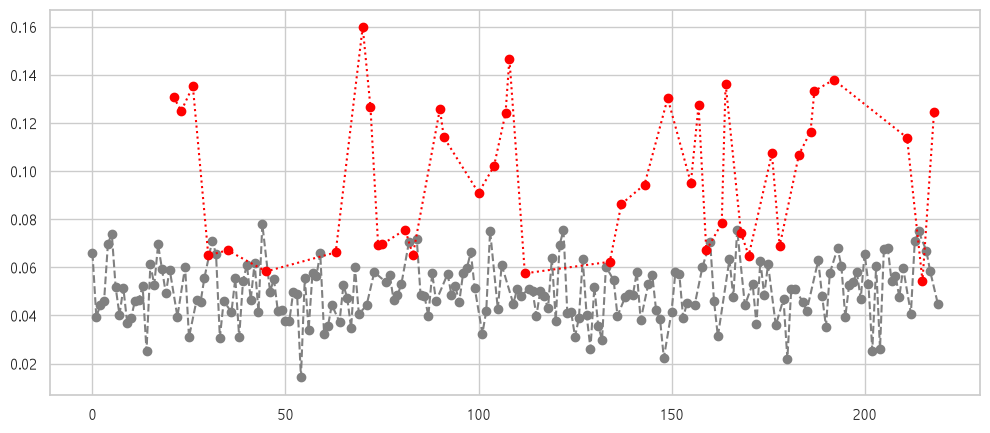

In [18]:
plt.figure(figsize=(12,5))
plt.plot(mimii.loc[mimii["label"] == 0, "rms"], color="gray", marker='o', linestyle='--')
plt.plot(mimii.loc[mimii["label"] == 1, "rms"], color="red", marker="o", linestyle=":")
plt.show()

In [19]:
# 실습3 코드

# 정상 행 골라내기
normal = mimii[mimii['label'] == 0] # label이 0일 떄
print(normal.head().to_markdown())
print()

# 정상 개수 확인
print("정상 개수:", normal['label'].value_counts())


# 세 특징 평균과 표준편차 출력
print("\n=== 이하 정상값 feature 평균 표준편차 ===")
rms_mean, rms_std = normal['rms'].mean(), normal['rms'].std()
print(f"rms 평균: {rms_mean} | 표준편차: {rms_std}")
print()
sc_mean, sc_std = normal['spectral_centroid'].mean(), normal['spectral_centroid'].std()
print(f"spectral_centroid 평균: {sc_mean} | 표준편차: {sc_std}")
print()
zcr_mean, zcr_std = normal['zero_crossing_rate'].mean(), normal['zero_crossing_rate'].std()
print(f"zero_crossing_rate 평균: {sc_mean} | 표준편차: {sc_std}")

|    |    rms |   spectral_centroid |   zero_crossing_rate |   label |
|---:|-------:|--------------------:|---------------------:|--------:|
|  0 | 0.0659 |              1982.7 |               0.1171 |       0 |
|  1 | 0.0393 |              2160.8 |               0.0821 |       0 |
|  2 | 0.0443 |              2065.9 |               0.091  |       0 |
|  3 | 0.0458 |              1884.4 |               0.1072 |       0 |
|  4 | 0.0698 |              2430.9 |               0.0864 |       0 |

정상 개수: label
0    180
Name: count, dtype: int64

=== 이하 정상값 feature 평균 표준편차 ===
rms 평균: 0.04997222222222223 | 표준편차: 0.012206336185720635

spectral_centroid 평균: 1979.0988888888887 | 표준편차: 239.17558870711576

zero_crossing_rate 평균: 1979.0988888888887 | 표준편차: 239.17558870711576


### 실습 4. rms Z-score 계산과 최댓값
목표 : rms를 정상 기준으로 Z-score로 바꾸고 가장 튄 값을 찾기

단계
- 정상 평균·표준편차로 Z-score를 계산
- 결과를 새 열로 담기
- Z가 큰 순으로 정렬해 가장 튄 샘플 확인

예상 결과
- 가장 튄 Z가 약 9로 정상에서 크게 벗어남


In [20]:
# 실습4 코드
normal.info()
mimii["z_rms"] = (mimii["rms"] - rms_mean) / rms_std
print("\n=== z_rms 내림차순 정렬 출력 ===")
print(mimii["z_rms"].sort_values(ascending=False).head(10).to_markdown())

<class 'pandas.DataFrame'>
Index: 180 entries, 0 to 219
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   rms                 180 non-null    float64
 1   spectral_centroid   180 non-null    float64
 2   zero_crossing_rate  180 non-null    float64
 3   label               180 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 7.0 KB

=== z_rms 내림차순 정렬 출력 ===
|     |   z_rms |
|----:|--------:|
|  70 | 9.0058  |
| 108 | 7.92439 |
| 192 | 7.21165 |
| 164 | 7.07237 |
|  26 | 6.99045 |
| 187 | 6.8266  |
|  21 | 6.62179 |
| 149 | 6.58083 |
| 157 | 6.33505 |
|  72 | 6.2859  |


### 실습 5. 임계값 적용과 2·3 비교
목표 : 절댓값 기준으로 이상을 표시하고 임계값 2와 3 결과를 비교

단계
- Z의 절댓값을 구하기
- 절댓값이 3을 넘으면 이상으로 표시
- 임계값 2와 3의 탐지 개수를 비교

예상 결과
- 임계값 3은 23건, 2는 36건 (낮출수록 많이 잡힘)

In [21]:
# 실습5 코드
# Z의 절댓값을 구하기
mimii["z_rms"] = np.abs(mimii["rms"] - rms_mean) / rms_std

# 3을 넘으면 이상으로 표시
anomaly_3 = mimii[mimii["z_rms"] > 3]

# 2와 3의 탐지 개수 비교
anomaly_2 = mimii[mimii["z_rms"] > 2]


print(anomaly_3.shape)
print(anomaly_2.shape)

(23, 5)
(36, 5)


> anomaly_3 는 23개  
> anomaly_2 는 36개  

### 실습 6. 세 특징 종합 판정
목표: 세 특징에 각각 Z-score를 적용하고 하나라도 넘으면 이상으로 종합

단계
- 세 특징마다 정상 기준으로 Z를 계산
- 특징 중 하나라도 절댓값이 3을 넘으면 이상 표시
- rms 단독 결과와 종합 결과를 비교

예상 결과
- 종합 이상은 39건으로 rms 단독 23건보다 많음

In [22]:
# 실습6 코드
print(mimii.head().to_markdown())
print()
print(normal.head().to_markdown())

|    |    rms |   spectral_centroid |   zero_crossing_rate |   label |    z_rms |
|---:|-------:|--------------------:|---------------------:|--------:|---------:|
|  0 | 0.0659 |              1982.7 |               0.1171 |       0 | 1.30488  |
|  1 | 0.0393 |              2160.8 |               0.0821 |       0 | 0.874318 |
|  2 | 0.0443 |              2065.9 |               0.091  |       0 | 0.464695 |
|  3 | 0.0458 |              1884.4 |               0.1072 |       0 | 0.341808 |
|  4 | 0.0698 |              2430.9 |               0.0864 |       0 | 1.62438  |

|    |    rms |   spectral_centroid |   zero_crossing_rate |   label |
|---:|-------:|--------------------:|---------------------:|--------:|
|  0 | 0.0659 |              1982.7 |               0.1171 |       0 |
|  1 | 0.0393 |              2160.8 |               0.0821 |       0 |
|  2 | 0.0443 |              2065.9 |               0.091  |       0 |
|  3 | 0.0458 |              1884.4 |               0.1072 |       0 |

In [23]:
# # 세 특징 평균과 표준편차 출력
# print("\n=== 이하 정상값 feature 평균 표준편차 ===")
# rms_mean, rms_std = normal["rms"].mean(), normal["rms"].std()
# print(f"rms 평균: {rms_mean} | 표준편차: {rms_std}")
# print()
# sc_mean, sc_std = normal["spectral_centroid"].mean(), normal["spectral_centroid"].std()
# print(f"spectral_centroid 평균: {sc_mean} | 표준편차: {sc_std}")
# print()
# zcr_mean, zcr_std = (
#     normal["zero_crossing_rate"].mean(),
#     normal["zero_crossing_rate"].std(),
# )
# print(f"zero_crossing_rate 평균: {sc_mean} | 표준편차: {sc_std}")

# 세 특징마다 정상 기준으로 Z를 계산
mimii['z_sc'] = np.abs(mimii['spectral_centroid'] - sc_mean) / sc_std
mimii['z_zcr'] = np.abs(mimii['zero_crossing_rate'] - zcr_mean) / zcr_std

mimii.head()

,rms,spectral_centroid,zero_crossing_rate,label,z_rms,z_sc,z_zcr
0,0.0659,1982.7,0.1171,0,1.304878,0.015056,1.379323
1,0.0393,2160.8,0.0821,0,0.874318,0.759698,0.468731
2,0.0443,2065.9,0.0910,0,0.464695,0.362918,0.001203
3,0.0458,1884.4,0.1072,0,0.341808,0.395939,0.856588
4,0.0698,2430.9,0.0864,0,1.624384,1.888993,0.241684


In [24]:
anomaly_sc_3 = mimii[mimii["z_sc"] > 3].drop(columns=["rms", "zero_crossing_rate"])
print(anomaly_sc_3.head().to_markdown())
print(anomaly_sc_3.shape)
print()

anomaly_zcr_3 = mimii[mimii['z_zcr'] > 3].drop(columns=['rms', 'spectral_centroid'])
print(anomaly_zcr_3.head().to_markdown())
print(anomaly_zcr_3.shape)

|    |   spectral_centroid |   label |   z_rms |    z_sc |    z_zcr |
|---:|--------------------:|--------:|--------:|--------:|---------:|
|  5 |              2728.5 |       0 | 1.96847 | 3.13327 | 0.386654 |
| 23 |              2846.4 |       1 | 6.14663 | 3.62621 | 1.17627  |
| 30 |              2950.1 |       1 | 1.23115 | 4.05978 | 2.41951  |
| 35 |              2895.5 |       1 | 1.40319 | 3.8315  | 2.91057  |
| 45 |              2835.7 |       1 | 0.68225 | 3.58147 | 3.26962  |
(16, 5)

|     |   zero_crossing_rate |   label |   z_rms |    z_sc |   z_zcr |
|----:|---------------------:|--------:|--------:|--------:|--------:|
|   9 |               0.1481 |       0 | 1.07913 | 2.00732 | 3.01617 |
|  45 |               0.1529 |       1 | 0.68225 | 3.58147 | 3.26962 |
|  74 |               0.1584 |       1 | 1.56704 | 2.4735  | 3.56003 |
| 159 |               0.1722 |       1 | 1.39499 | 3.02707 | 4.28869 |
| 170 |               0.157  |       1 | 1.22295 | 2.66457 | 3.48611 |
(5, 

### 실습 7. 탐지 결과 정비 문장으로 정리
목표: 가장 튄 이상 샘플을 사람이 읽을 정비 문장으로 옮기기

단계
- 이상으로 표시된 것 중 Z 절댓값 상위 몇 개 고르기
- 각 샘플의 벗어난 방향과 배수를 확인
- 점검 권장 문장으로 출력

예상 결과
- 소리 세기가 표준편차 몇 배 위로 벗어남, 점검 권장 문장

In [25]:
# 실습7 코드
threshold = 3

z_info = {
    "z_rms": ("rms", "소리 세기(rms)", rms_mean, rms_std),
    "z_sc": ("spectral_centroid", "주파수 중심(spectral_centroid)", sc_mean, sc_std),
    "z_zcr": ("zero_crossing_rate", "영교차율(zero_crossing_rate)", zcr_mean, zcr_std),
}

records = []
for idx, row in mimii.iterrows():
    for z_col, (raw_col, name_kr, mean_v, std_v) in z_info.items():
        z = row[z_col]
        if z > threshold:
            direction = "위" if row[raw_col] >= mean_v else "아래"
            records.append((idx, name_kr, z, direction))

# Z 절댓값이 큰 순서로 상위 5건만 정비 문장으로 정리
records.sort(key=lambda r: r[2], reverse=True)

print("=== 정비 점검 리포트 (Z 상위 5건) ===")
for idx, name_kr, z, direction in records[:5]:
    print(f"[인덱스 {idx}] {name_kr}가 정상 평균보다 {direction}로 표준편차의 {z:.1f}배 벗어남 → 점검 권장")


=== 정비 점검 리포트 (Z 상위 5건) ===
[인덱스 70] 소리 세기(rms)가 정상 평균보다 위로 표준편차의 9.0배 벗어남 → 점검 권장
[인덱스 108] 소리 세기(rms)가 정상 평균보다 위로 표준편차의 7.9배 벗어남 → 점검 권장
[인덱스 192] 소리 세기(rms)가 정상 평균보다 위로 표준편차의 7.2배 벗어남 → 점검 권장
[인덱스 164] 소리 세기(rms)가 정상 평균보다 위로 표준편차의 7.1배 벗어남 → 점검 권장
[인덱스 26] 소리 세기(rms)가 정상 평균보다 위로 표준편차의 7.0배 벗어남 → 점검 권장


### 실습 8. Z-score가 놓친 이상 확인
목표: rms 하나로는 놓친 진짜 이상을 찾고 두 특징 산점도로 확인

단계
- 임계값을 넘지 않았는데 실제로는 이상인 샘플을 골라내기
- 놓친 개수를 세기
- 두 특징 산점도에서 정상 속 이상 위치 확인

예상 결과
- rms 단독으로 17건을 놓침 — 한 특징만으로는 부족

rms 단독 탐지: 23 건
rms 단독이 놓친 진짜 이상: 17 건


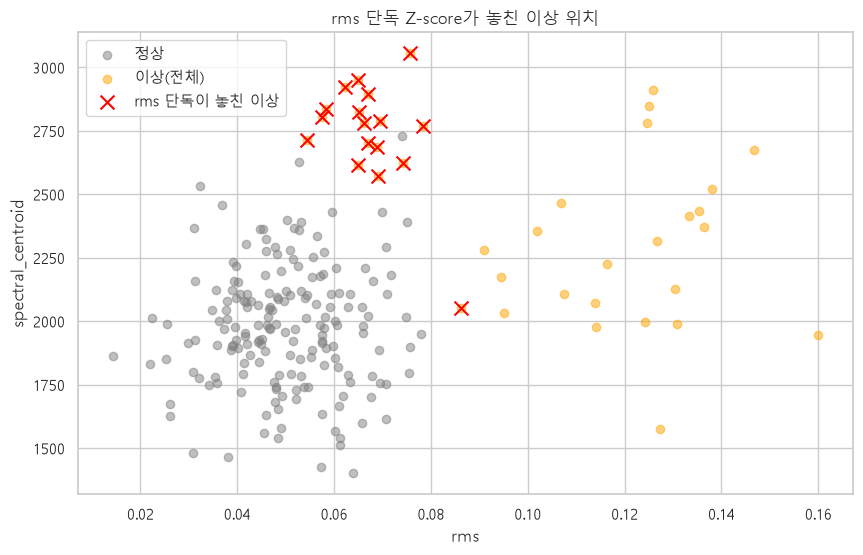

In [26]:
# 실습8 코드
# rms 단독 기준(z_rms > 3)으로는 안 걸렸지만 실제로는 이상인 샘플
missed = mimii[(mimii["z_rms"] <= threshold) & (mimii["label"] == 1)]
print("rms 단독 탐지:", len(anomaly_3), "건")
print("rms 단독이 놓친 진짜 이상:", len(missed), "건")

# 두 특징 산점도로 놓친 이상의 위치 확인
plt.figure(figsize=(10, 6))
plt.scatter(mimii.loc[mimii["label"] == 0, "rms"], mimii.loc[mimii["label"] == 0, "spectral_centroid"],
            c="gray", alpha=0.5, label="정상")
plt.scatter(mimii.loc[mimii["label"] == 1, "rms"], mimii.loc[mimii["label"] == 1, "spectral_centroid"],
            c="orange", alpha=0.5, label="이상(전체)")
plt.scatter(missed["rms"], missed["spectral_centroid"],
            c="red", marker="x", s=100, label="rms 단독이 놓친 이상")
plt.xlabel("rms")
plt.ylabel("spectral_centroid")
plt.title("rms 단독 Z-score가 놓친 이상 위치")
plt.legend()
plt.show()
